# GHG model plots

Select a completed GHG run and create its publication-ready figures.

In [ ]:
# Enter the exact GHG run-directory name here.
RUN_NAME = "fleet_size_no_change__2026-08-28_120918"

In [18]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_final_model_dir() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if candidate.name == "Final_Model":
            return candidate
        nested = candidate / "Final_Model"
        if nested.is_dir():
            return nested
    raise FileNotFoundError("Could not locate the Final_Model directory.")


FINAL_MODEL_DIR = find_final_model_dir()
RUN_DIR = FINAL_MODEL_DIR / "outputs" / "ghg_model" / RUN_NAME
if not RUN_DIR.is_dir():
    output_root = FINAL_MODEL_DIR / "outputs" / "ghg_model"
    available_runs = sorted(path.name for path in output_root.glob("*") if path.is_dir())
    raise FileNotFoundError(
        f"GHG run not found: {RUN_DIR}\nAvailable runs: {available_runs}"
    )

manifest_path = RUN_DIR / "run_manifest.json"
if not manifest_path.is_file():
    raise FileNotFoundError(f"Run manifest not found: {manifest_path}")
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
if manifest.get("status") != "success":
    raise ValueError(
        f"Run {RUN_NAME!r} has status {manifest.get('status')!r}; "
        "plots are only created for successful runs."
    )

run_prefix = manifest.get("run_name")
if not run_prefix:
    raise ValueError(f"Manifest has no run_name: {manifest_path}")

def load_result(table_name: str) -> pd.DataFrame:
    path = RUN_DIR / f"{run_prefix}__{table_name}.csv"
    if not path.is_file():
        raise FileNotFoundError(f"GHG result not found: {path}")
    return pd.read_csv(path, sep=";", encoding="utf-8-sig")


emissions_by_phase = load_result("emissions_by_phase")
emissions_summary_by_year_phase = load_result("emissions_summary_by_year_phase")
emissions_summary_by_year_total = load_result("emissions_summary_by_year_total")

print(f"Selected run:  {RUN_NAME}")
print(f"Run status:    {manifest['status']}")
print(f"Fleet input:   {manifest['fleet_input']['run_directory_name']}")
print(f"Emission rows: {len(emissions_by_phase):,}")

Selected run:  fleet_size_no_change_pout26__2026-09-03_153915
Run status:    success
Fleet input:   fleet_size_no_change_pout26__2026-09-03_153915
Emission rows: 679,492


## Annual GHG emissions by life-cycle phase and scenario

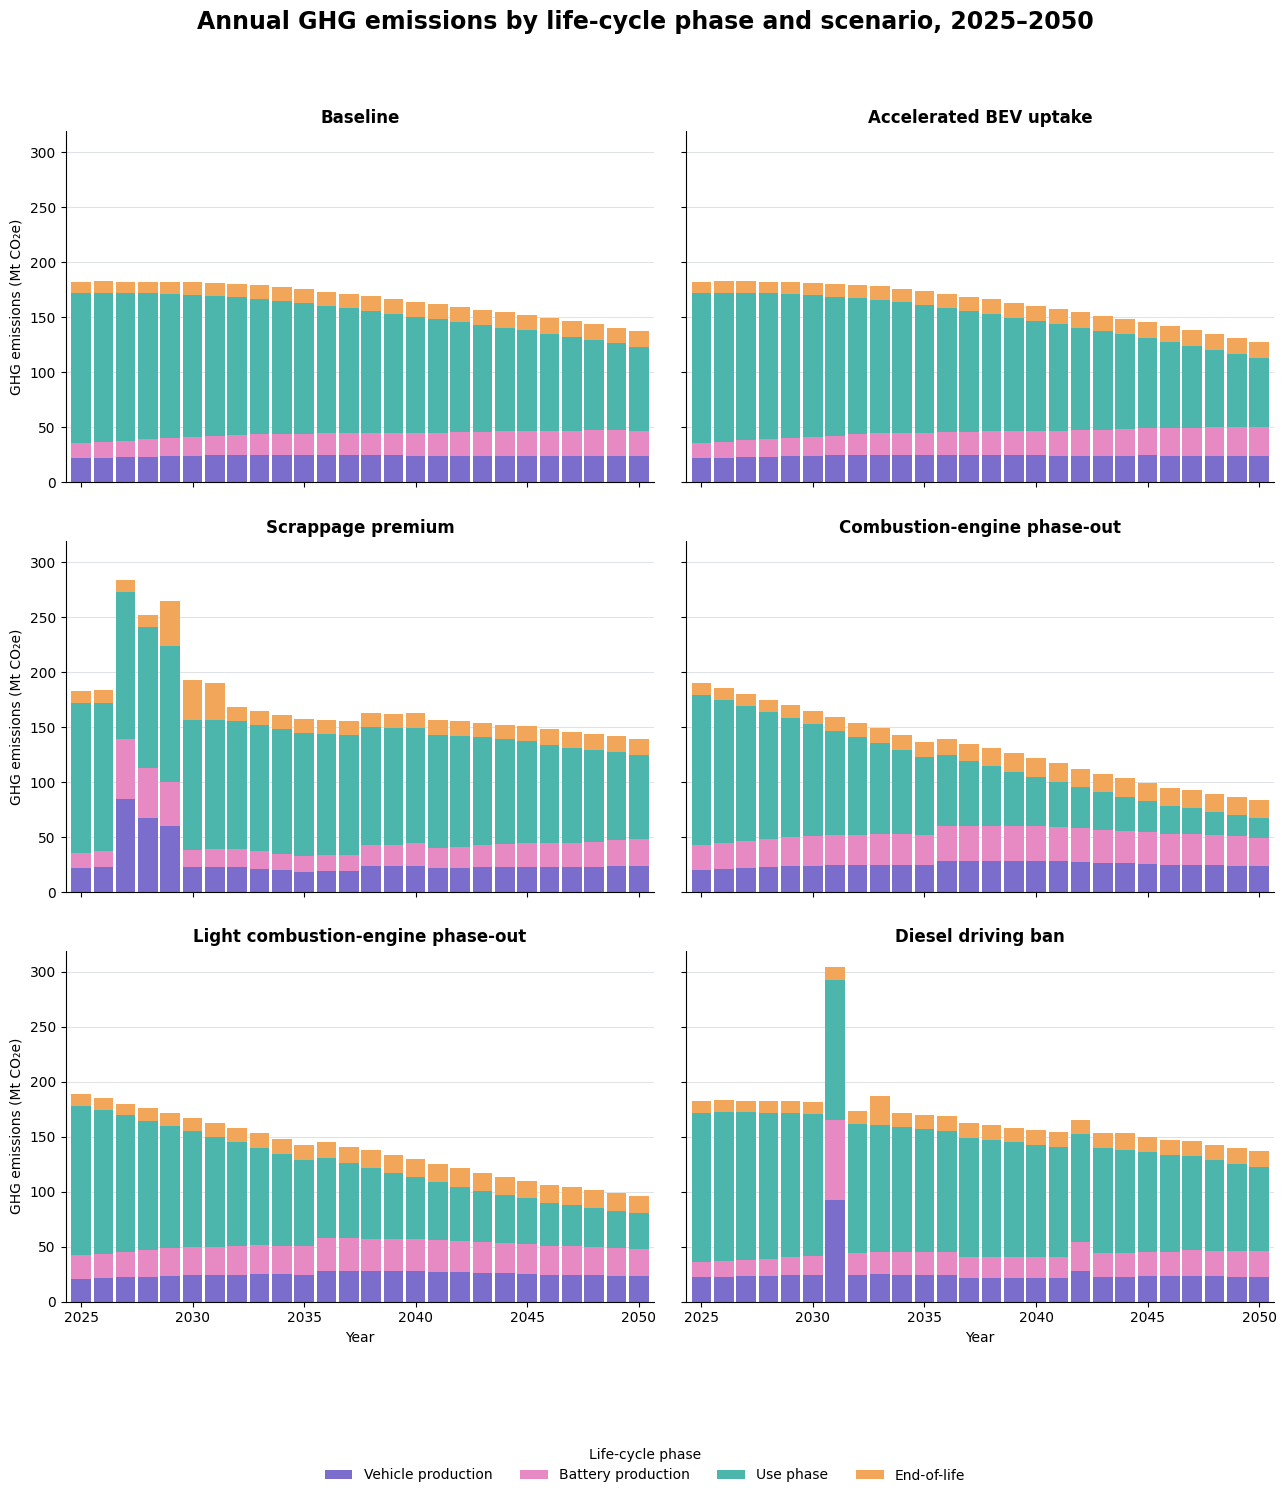

Figure saved to:
C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Final_Model\outputs\ghg_model\fleet_size_no_change_pout26__2026-09-03_153915\annual_ghg_emissions_by_phase_and_scenario_2025_2050.png


In [19]:
plot_emissions = emissions_by_phase.copy()
required_columns = ["Szenario", "emission_year", "phase", "emissions_tco2e"]
missing_columns = [column for column in required_columns if column not in plot_emissions.columns]
if missing_columns:
    raise ValueError(f"Missing columns in emissions_by_phase: {missing_columns}")

plot_emissions["emission_year"] = pd.to_numeric(plot_emissions["emission_year"], errors="coerce")
plot_emissions["emissions_tco2e"] = pd.to_numeric(plot_emissions["emissions_tco2e"], errors="coerce")
plot_emissions = plot_emissions.dropna(subset=["emission_year"])
plot_emissions["emission_year"] = plot_emissions["emission_year"].astype(int)
plot_emissions["emissions_tco2e"] = plot_emissions["emissions_tco2e"].fillna(0.0)
plot_emissions = plot_emissions[plot_emissions["emission_year"].between(2025, 2050)]

scenario_order = [
    "baseline_ev_growth", "stronger_ev_growth", "abwrackpraemie",
    "verbrenneraus_2035", "verbrenneraus_light", "diesel_fahrverbot",
]
scenario_labels = {
    "baseline_ev_growth": "Baseline",
    "stronger_ev_growth": "Accelerated BEV uptake",
    "abwrackpraemie": "Scrappage premium",
    "verbrenneraus_2035": "Combustion-engine phase-out",
    "verbrenneraus_light": "Light combustion-engine phase-out",
    "diesel_fahrverbot": "Diesel driving ban",
}
phase_order = ["production", "battery_production", "use", "end_of_life"]
phase_labels = {
    "production": "Vehicle production",
    "battery_production": "Battery production",
    "use": "Use phase",
    "end_of_life": "End-of-life",
}
phase_colors = {
    "production": "#7B6DCC",
    "battery_production": "#E78AC3",
    "use": "#4DB6AC",
    "end_of_life": "#F2A65A",
}

emissions_plot_agg = plot_emissions.groupby(
    ["Szenario", "emission_year", "phase"], as_index=False
)["emissions_tco2e"].sum()
available_scenarios = set(emissions_plot_agg["Szenario"].unique())
missing_scenarios = [scenario for scenario in scenario_order if scenario not in available_scenarios]
if missing_scenarios:
    raise ValueError(f"Scenarios missing from emissions_by_phase: {missing_scenarios}")

fig, axes = plt.subplots(3, 2, figsize=(13, 15), sharex=True, sharey=True, squeeze=False)
years = range(2025, 2051)
colors = [phase_colors[phase] for phase in phase_order]
for ax, scenario in zip(axes.flat, scenario_order):
    panel_data = (
        emissions_plot_agg.loc[emissions_plot_agg["Szenario"] == scenario]
        .pivot_table(index="emission_year", columns="phase", values="emissions_tco2e", aggfunc="sum", fill_value=0.0)
        .reindex(index=years, columns=phase_order, fill_value=0.0) / 1_000_000
    )
    panel_data.rename(columns=phase_labels).plot(
        kind="bar", stacked=True, ax=ax, width=0.88, color=colors, edgecolor="none", legend=False
    )
    ax.set_title(scenario_labels[scenario], fontsize=12, fontweight="semibold")
    ax.set_xlabel("Year")
    ax.set_ylabel("GHG emissions (Mt CO₂e)")
    tick_positions = list(range(0, len(panel_data.index), 5))
    if len(panel_data.index) - 1 not in tick_positions:
        tick_positions.append(len(panel_data.index) - 1)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([panel_data.index[i] for i in tick_positions], rotation=0)
    ax.grid(axis="y", color="#D1D5DB", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

handles, _ = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, [phase_labels[phase] for phase in phase_order], title="Life-cycle phase", loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Annual GHG emissions by life-cycle phase and scenario, 2025–2050", fontsize=17, fontweight="bold")
fig.tight_layout(rect=[0, 0.08, 1, 0.95], h_pad=2.0, w_pad=1.5)
output_path = RUN_DIR / "annual_ghg_emissions_by_phase_and_scenario_2025_2050.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figure saved to:\n{output_path}")

## Cumulative GHG emissions by scenario and life-cycle phase

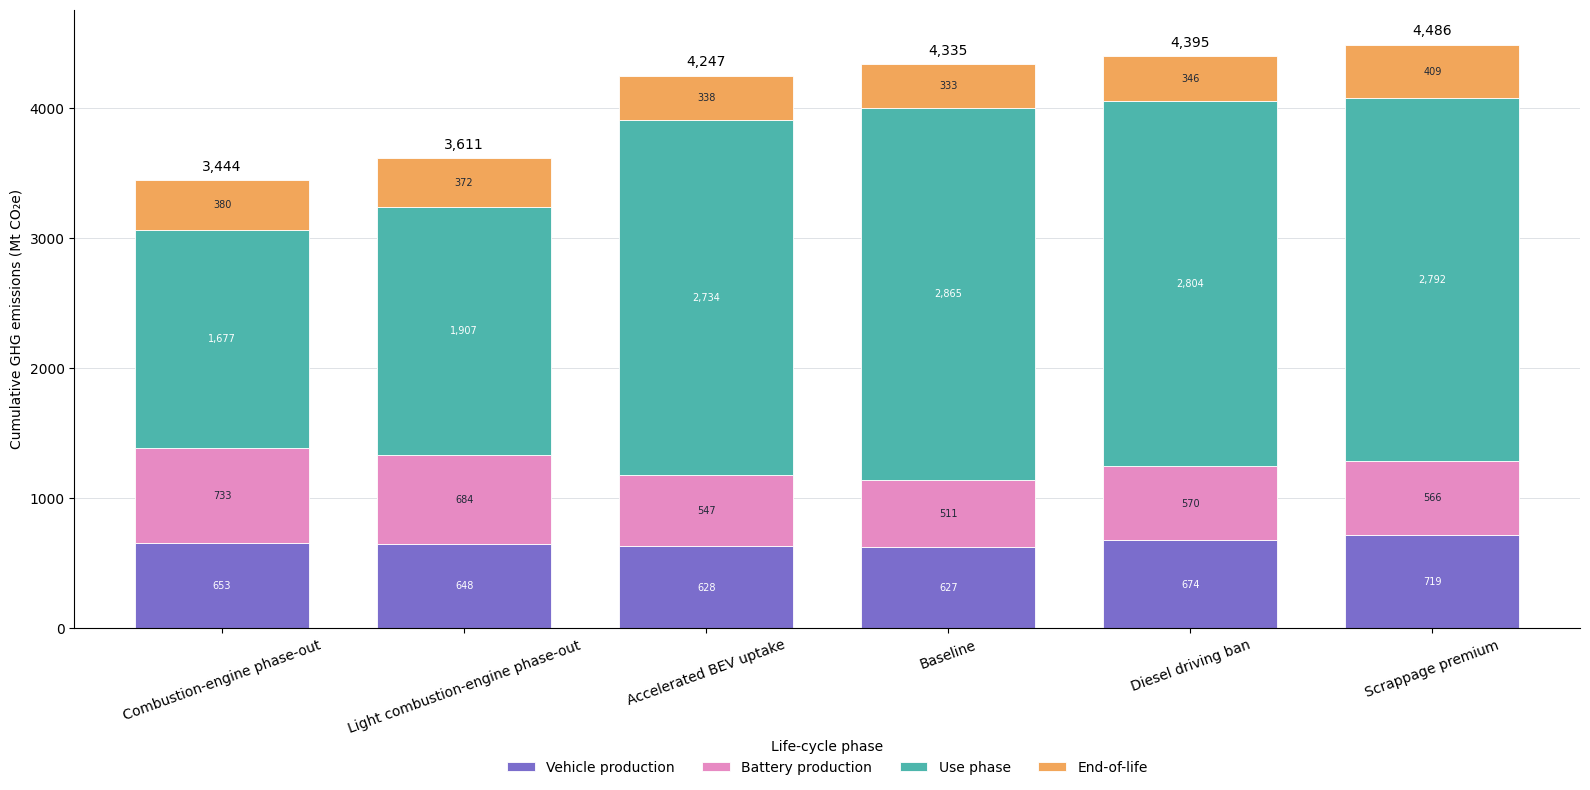

Figure saved to:
C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Final_Model\outputs\ghg_model\fleet_size_no_change_pout26__2026-09-03_153915\cumulative_ghg_emissions_by_scenario_and_phase_2025_2050.png
CSV data saved to:
C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Final_Model\outputs\ghg_model\fleet_size_no_change_pout26__2026-09-03_153915\cumulative_ghg_emissions_by_scenario_and_phase_2025_2050.csv


In [20]:
cumulative_source = emissions_by_phase.copy()
cumulative_source["emission_year"] = pd.to_numeric(cumulative_source["emission_year"], errors="coerce")
cumulative_source["emissions_tco2e"] = pd.to_numeric(cumulative_source["emissions_tco2e"], errors="coerce").fillna(0.0)
cumulative_source = cumulative_source[cumulative_source["emission_year"].between(2025, 2050)]

cumulative_plot = (
    cumulative_source.groupby(["Szenario", "phase"])["emissions_tco2e"].sum()
    .unstack(fill_value=0.0)
    .reindex(index=scenario_order, columns=phase_order, fill_value=0.0) / 1_000_000
)
cumulative_plot.index = [scenario_labels[scenario] for scenario in cumulative_plot.index]
cumulative_plot = cumulative_plot.rename(columns=phase_labels)
cumulative_plot = cumulative_plot.loc[cumulative_plot.sum(axis=1).sort_values().index]
totals = cumulative_plot.sum(axis=1)

fig, ax = plt.subplots(figsize=(16, 8))
cumulative_plot.plot(
    kind="bar", stacked=True, ax=ax, width=0.72,
    color=[phase_colors[phase] for phase in phase_order], edgecolor="white", linewidth=0.6,
)
for position, (_, row) in enumerate(cumulative_plot.iterrows()):
    lower_edge = 0.0
    for phase_label, phase_value in row.items():
        if phase_value > 0:
            ax.text(position, lower_edge + phase_value / 2, f"{phase_value:,.0f}", ha="center", va="center", fontsize=7, color="white" if phase_label in {"Vehicle production", "Use phase"} else "#1F2937")
        lower_edge += phase_value
label_offset = max(totals.max() * 0.012, 1.0)
for position, total in enumerate(totals):
    ax.text(position, total + label_offset, f"{total:,.0f}", ha="center", va="bottom", fontsize=10)
ax.set_xlabel("")
ax.set_ylabel("Cumulative GHG emissions (Mt CO₂e)")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", color="#D1D5DB", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Life-cycle phase", ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.16), frameon=False)
ax.set_ylim(0, totals.max() + 5 * label_offset)
fig.tight_layout()
output_path = RUN_DIR / "cumulative_ghg_emissions_by_scenario_and_phase_2025_2050.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figure saved to:\n{output_path}")

cumulative_csv = cumulative_plot.copy()
cumulative_csv["Total"] = cumulative_csv.sum(axis=1)
cumulative_csv.index.name = "Scenario"
csv_output_path = RUN_DIR / "cumulative_ghg_emissions_by_scenario_and_phase_2025_2050.csv"
cumulative_csv.to_csv(csv_output_path, encoding="utf-8-sig", float_format="%.6f")
print(f"CSV data saved to:\n{csv_output_path}")

## German transport emission targets and modelled scenario emissions

The German transport emission target values were calculated in the Excel file `Emissionziele`.

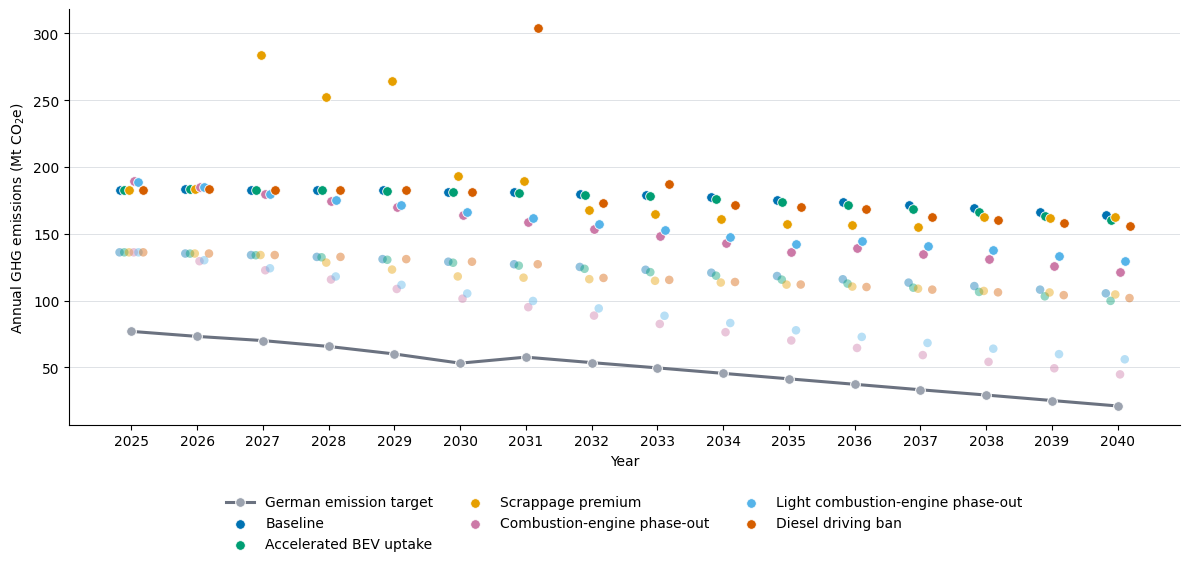

Figure saved to:
C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Final_Model\outputs\ghg_model\fleet_size_no_change_pout26__2026-09-03_153915\german_emission_targets_and_modelled_scenarios_2025_2040.png
CSV data saved to:
C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Final_Model\outputs\ghg_model\fleet_size_no_change_pout26__2026-09-03_153915\german_emission_targets_and_modelled_scenarios_2025_2040.csv


In [21]:
target_emissions = pd.Series(
    [77.01468, 73.25786, 70.12718, 65.74423, 60.10901, 53.22152, 57.73753, 53.64368, 49.69098, 45.59712, 41.50326, 37.40941, 33.31555, 29.36285, 25.26899, 21.17513],
    index=range(2025, 2041), name="German emission target",
)
target_scenario_order = scenario_order
target_scenario_labels = scenario_labels
target_scenario_colors = {
    "baseline_ev_growth": "#0072B2", "stronger_ev_growth": "#009E73",
    "abwrackpraemie": "#E69F00", "diesel_fahrverbot": "#D55E00",
    "verbrenneraus_2035": "#CC79A7", "verbrenneraus_light": "#56B4E9",
}
modelled_target_years = emissions_summary_by_year_total.loc[
    emissions_summary_by_year_total["emission_year"].between(2025, 2040)
].copy()
modelled_target_years["emissions_MtCO2e"] = modelled_target_years["total_emissions_tco2e"] / 1_000_000
use_phase_target_years = (
    emissions_summary_by_year_phase.loc[
        emissions_summary_by_year_phase["emission_year"].between(2025, 2040)
        & emissions_summary_by_year_phase["phase"].eq("use")
    ].groupby(["Szenario", "emission_year"], as_index=False)["emissions_tco2e"].sum()
)
use_phase_target_years["emissions_MtCO2e"] = use_phase_target_years["emissions_tco2e"] / 1_000_000

target_plot_csv = (
    modelled_target_years[["Szenario", "emission_year", "total_emissions_tco2e", "emissions_MtCO2e"]]
    .rename(columns={"emissions_MtCO2e": "total_emissions_MtCO2e"})
    .merge(
        use_phase_target_years[["Szenario", "emission_year", "emissions_tco2e", "emissions_MtCO2e"]]
        .rename(columns={
            "emissions_tco2e": "use_phase_emissions_tco2e",
            "emissions_MtCO2e": "use_phase_emissions_MtCO2e",
        }),
        on=["Szenario", "emission_year"],
        how="left",
        validate="one_to_one",
    )
    .sort_values(["emission_year", "Szenario"])
)
target_plot_csv.insert(1, "Scenario", target_plot_csv["Szenario"].map(target_scenario_labels).fillna(target_plot_csv["Szenario"]))

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(target_emissions.index, target_emissions.values, color="#6B7280", linewidth=2.2, marker="o", markersize=7, markerfacecolor="#9CA3AF", markeredgecolor="white", markeredgewidth=0.7, zorder=1, label="German emission target")
available_target_scenarios = set(modelled_target_years["Szenario"].unique())
plot_order = [scenario for scenario in target_scenario_order if scenario in available_target_scenarios]
plot_order += sorted(available_target_scenarios - set(plot_order))
fallback_colors = plt.cm.tab10.colors
point_offsets = np.linspace(-0.18, 0.18, len(plot_order)) if len(plot_order) > 1 else [0.0]
for index, scenario in enumerate(plot_order):
    scenario_data = modelled_target_years.loc[modelled_target_years["Szenario"].eq(scenario)].sort_values("emission_year")
    color = target_scenario_colors.get(scenario, fallback_colors[index % len(fallback_colors)])
    ax.scatter(scenario_data["emission_year"] + point_offsets[index], scenario_data["emissions_MtCO2e"], s=48, color=color, edgecolor="white", linewidth=0.6, zorder=2, label=target_scenario_labels.get(scenario, scenario))
    use_phase_data = use_phase_target_years.loc[use_phase_target_years["Szenario"].eq(scenario)].sort_values("emission_year")
    ax.scatter(use_phase_data["emission_year"] + point_offsets[index], use_phase_data["emissions_MtCO2e"], s=38, color=color, alpha=0.42, edgecolor="none", zorder=2, label="_nolegend_")
ax.set_xlabel("Year")
ax.set_ylabel("Annual GHG emissions (Mt CO$_2$e)")
ax.set_xticks(target_emissions.index)
ax.grid(axis="y", color="#D1D5DB", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.14), frameon=False)
fig.tight_layout(rect=[0, 0.15, 1, 1])
output_path = RUN_DIR / "german_emission_targets_and_modelled_scenarios_2025_2040.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figure saved to:\n{output_path}")

csv_output_path = RUN_DIR / "german_emission_targets_and_modelled_scenarios_2025_2040.csv"
target_plot_csv.to_csv(csv_output_path, index=False, encoding="utf-8-sig", float_format="%.6f")
print(f"CSV data saved to:\n{csv_output_path}")